# Does Face Blurring Degrade Pose Estimation?

Pipeline: **video -> pose (ground truth) -> face censor -> pose again -> compare**.

- **Censoring** is taken from [`blurfaces`](https://github.com/AlexPasqua/blurfaces) (`apply_censor`: `blur` / `blackout` / `pixel` / `bar`), with OpenCV video I/O instead of ffmpeg pipes so it runs on Windows without extra binaries.
- **Pose estimation** defaults to torchvision's **Keypoint R-CNN** (COCO-17), which downloads its own weights and runs on the GPU with no build step. [AlphaPose](https://github.com/MVIG-SJTU/AlphaPose) is vendored in `vendor/AlphaPose/` and wired up as a second backend — see the note in section 2 for what it still needs before it can run.
- Both backends are normalised to **COCO-17**, so every downstream cell is backend-agnostic. Halpe-26's first 17 joints are already in COCO order.

Designed for **action poses**, so the comparison focuses on the failure modes that actually matter there: dropped detections, face-keypoint (nose/eyes/ears) displacement, and confidence collapse.

**Just run every cell top to bottom.** Missing packages install themselves, model weights download on first use, and section 5 renders a GIF inline plus four video files.

## 0. Setup

Installs anything missing, then sets every knob in one place. Nothing here needs editing for a first run.

In [27]:
import importlib.util, subprocess, sys

# (import name, pip name) — installed only if absent, so re-running is free.
NEEDED = [("cv2", "opencv-python"), ("numpy", "numpy"), ("matplotlib", "matplotlib"),
          ("tqdm", "tqdm"), ("PIL", "pillow"), ("torch", "torch"), ("torchvision", "torchvision")]

missing = [pip for mod, pip in NEEDED if not importlib.util.find_spec(mod)]
if missing:
    print("installing:", *missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("done — if imports fail below, restart the kernel and re-run.")
else:
    print("all required packages present")

all required packages present


In [28]:
import json, os, shutil, subprocess, sys, tempfile
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PROJECT = Path.cwd()
INPUT_DIR  = PROJECT / "input"
OUTPUT_DIR = PROJECT / "output"
WORK_DIR   = PROJECT / "work"
VENDOR_DIR = PROJECT / "vendor"
for d in (INPUT_DIR, OUTPUT_DIR, WORK_DIR):
    d.mkdir(exist_ok=True)


@dataclass
class Config:
    # ---- censoring (from blurfaces) ----
    blur_method: str = "blur"        # blur | blackout | pixel | bar
    mode: str = "all"                # all | target | exclude
    face_file: str | None = None     # reference photo, required for target/exclude
    threshold: float = 0.45          # embedding match strictness, target/exclude only
    face_backend: str = "yunet"      # yunet (no build) | insightface (adds embeddings)
    model_pack: str = "buffalo_l"    # insightface only: buffalo_l | buffalo_s | buffalo_sc
    det_size: int = 640              # insightface only; raise to 960 for distant faces
    # Action poses: motion blur and profile views break face detection on
    # individual frames. Pad the box out, and hold the last known box for a
    # few frames so a momentary miss does not leave the face exposed.
    box_pad: float = 0.25            # fraction of box size to expand each side
    miss_hold: int = 3               # frames to keep censoring after a miss

    # ---- pose ----
    pose_backend: str = "torchvision"   # torchvision | alphapose
    pose_score_thr: float = 0.5      # min person score to keep a detection
    kpt_vis_thr: float = 0.2         # a keypoint only counts if the BEFORE run
                                     # was this confident it was visible
    # AlphaPose (see section 2 — needs weights and a separate env to run)
    alphapose_root: str = str(VENDOR_DIR / "AlphaPose")
    alphapose_cfg: str = "configs/halpe_26/resnet/256x192_res50_lr1e-3_1x.yaml"
    alphapose_ckpt: str = "pretrained_models/halpe26_fast_res50_256x192.pth"
    alphapose_python: str = sys.executable   # point at the AlphaPose env's python

    # ---- comparison / output ----
    pck_thresholds: tuple = (0.05, 0.10, 0.20)   # fraction of person bbox diagonal
    max_frames: int | None = 120     # cap for quick iteration; None = whole video
    draw_kpt_thr: float = 0.35       # overlay only: hide joints the model is
                                     # guessing at, so the skeleton stays legible
    gif_width: int = 800             # inline GIF width; 0 disables the GIF
    gif_fps: int = 8                 # lower = smaller file
    gif_max_frames: int = 40         # frames sampled across the clip
    gif_colors: int = 128            # palette size; lower = smaller file

CFG = Config()

print("cwd    :", PROJECT)
print("opencv :", cv2.__version__)
print("torch  :", torch.__version__, "| cuda:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu only")
print("pose   :", CFG.pose_backend, "| faces:", CFG.face_backend,
      "| censor:", CFG.blur_method)
print("frames :", CFG.max_frames or "all")

cwd    : c:\.FILES\..MY STUFF\..KARIN\.UI\.SEM 6\skripsi\..RA-Pak-Edy
opencv : 5.0.0
torch  : 2.14.0+cpu | cuda: False | cpu only
pose   : torchvision | faces: yunet | censor: blur
frames : 120


## 1. Select MP4 Videos

Drop your action clips into `input/`. The cell lists what it finds, probes each one, and sets `VIDEO` to the active choice.

1 video(s) in c:\.FILES\..MY STUFF\..KARIN\.UI\.SEM 6\skripsi\..RA-Pak-Edy\input:

  [0] Jim Lahey Falls Down - JackKehoe (480p).mp4 640x480  29.97 fps    276 frames     9.2s

Active: Jim Lahey Falls Down - JackKehoe (480p).mp4  ->  processing 120 frames


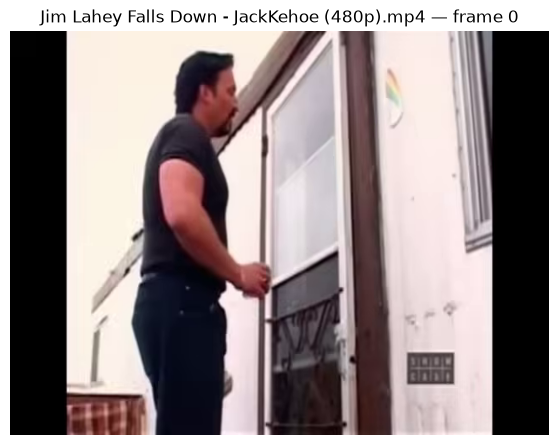

In [29]:
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}

def video_meta(path):
    """Probe *path* with OpenCV: (w, h, nframes, fps)."""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise IOError(f"cannot open {path}")
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()
    return w, h, n, fps


def frame_reader(path, limit=None):
    """Yield BGR frames."""
    cap = cv2.VideoCapture(str(path))
    try:
        i = 0
        while limit is None or i < limit:
            ok, frame = cap.read()
            if not ok:
                break
            yield frame
            i += 1
    finally:
        cap.release()


import contextlib

@contextlib.contextmanager
def quiet_stderr():
    """Mute OS-level stderr while OpenCV probes codecs.

    Targets file descriptor 2 directly rather than sys.stderr.fileno(): under
    Jupyter, sys.stderr is an ipykernel stream with no OS-level descriptor and
    asking for one raises. Degrades to a no-op if fd 2 is unavailable.
    """
    try:
        saved = os.dup(2)
    except Exception:
        yield
        return
    devnull = os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 2)
        yield
    finally:
        try:
            sys.stderr.flush()
        except Exception:
            pass
        os.dup2(saved, 2); os.close(devnull); os.close(saved)


_FOURCC = None

def _try_codec(tag, verify):
    """Open a writer for *tag*. With verify, also read the file back.

    cv2.VideoWriter.isOpened() returns True even when the H.264 encoder failed
    to initialise (pip's opencv ships without the openh264 DLL), so opening is
    not proof. Reading the frames back is.
    """
    probe = Path(tempfile.gettempdir()) / f"_cv2_probe_{tag}.mp4"
    blank = np.zeros((64, 64, 3), np.uint8)
    try:
        with quiet_stderr():
            vw = cv2.VideoWriter(str(probe), cv2.VideoWriter_fourcc(*tag), 25, (64, 64))
            opened = vw.isOpened()
            if opened:
                for _ in range(3):
                    vw.write(blank)
            vw.release()
            if not opened:
                return False
            if not verify:
                return True
            cap = cv2.VideoCapture(str(probe))
            ok = cap.read()[0] and int(cap.get(cv2.CAP_PROP_FOURCC)) != 0
            cap.release()
        return ok
    except Exception as exc:
        _probe_errors.append(f"{tag}: {type(exc).__name__}: {exc}")
        return False
    finally:
        probe.unlink(missing_ok=True)


_probe_errors = []

def _probe_fourcc():
    global _FOURCC
    if _FOURCC:
        return _FOURCC
    _probe_errors.clear()
    # First choice: a codec whose output we can actually read back.
    for tag in ("avc1", "mp4v"):
        if _try_codec(tag, verify=True):
            _FOURCC = tag
            break
    else:
        # Nothing verified. Accept a writer that at least opens rather than
        # failing outright — the GIF preview does not depend on this.
        for tag in ("mp4v", "avc1", "MJPG"):
            if _try_codec(tag, verify=False):
                _FOURCC = tag
                print(f"warning: could not verify any mp4 codec; using '{tag}' unchecked.")
                break
    if _FOURCC is None:
        sep = chr(10) + "  "
        detail = (sep + sep.join(_probe_errors)) if _probe_errors else ""
        raise IOError("OpenCV cannot write video in this environment." + detail)
    if _FOURCC != "avc1":
        print(f"note: H.264 unavailable, writing '{_FOURCC}'. Media players handle it "
              "fine; the inline preview in section 5 is a GIF, so it is unaffected.")
    return _FOURCC


def frame_writer(path, w, h, fps):
    tag = _probe_fourcc()
    with quiet_stderr():
        vw = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*tag), fps, (w, h))
    if not vw.isOpened():
        raise IOError(f"cannot open writer for {path}")
    return vw


def to_browser_mp4(src):
    """Transcode to real H.264 so Jupyter can play it inline.

    Uses the static ffmpeg binary that ships with imageio-ffmpeg — no system
    install. Returns *src* unchanged if that package is not present.
    """
    if _probe_fourcc() == "avc1":
        return src
    try:
        import imageio_ffmpeg
    except ImportError:
        return src
    dst = src.with_name(src.stem + "_h264.mp4")
    subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(), "-y", "-i", str(src),
                    "-c:v", "libx264", "-pix_fmt", "yuv420p", "-v", "error", str(dst)],
                   check=True)
    return dst


videos = sorted(p for p in INPUT_DIR.iterdir() if p.suffix.lower() in VIDEO_EXTS)
if not videos:
    raise SystemExit(f"No videos found. Put your clips in {INPUT_DIR}")

print(f"{len(videos)} video(s) in {INPUT_DIR}:\n")
for i, p in enumerate(videos):
    w, h, n, fps = video_meta(p)
    print(f"  [{i}] {p.name:<40} {w}x{h}  {fps:5.2f} fps  {n:5d} frames  {n/fps:6.1f}s")

# ---- pick one ----
SELECT = 0
VIDEO = videos[SELECT]
VW, VH, VN, VFPS = video_meta(VIDEO)
N_FRAMES = min(VN, CFG.max_frames) if CFG.max_frames else VN
STEM = VIDEO.stem

print(f"\nActive: {VIDEO.name}  ->  processing {N_FRAMES} frames")

# first frame, as a sanity check on orientation / content
_first = next(frame_reader(VIDEO))
plt.figure(figsize=(7, 7 * VH / VW))
plt.imshow(cv2.cvtColor(_first, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(f"{VIDEO.name} — frame 0"); plt.show()

## 2. Pose Estimation before Blur

Ground truth for the comparison: the same estimator, on the untouched video.

Both backends return the same structure — one entry per frame, each a list of people:

```python
{"kpts": (17, 3) float32 [x, y, score],  "box": (4,) [x1, y1, x2, y2],  "score": float}
```

**Why the default is torchvision, not AlphaPose.** The AlphaPose source is vendored at `vendor/AlphaPose/` and the backend below is wired to it, but it cannot run as-is, for two reasons that no amount of notebook code can fix:

1. **No weights.** The repo ships source only — `pretrained_models/` contains a single empty `get_models.sh`. The pose checkpoint (~140 MB) and the YOLO person detector (~240 MB) live behind Google Drive / Baidu links in `docs/MODEL_ZOO.md` and have to be fetched by hand.
2. **Four CUDA extensions.** `setup.py` compiles `nms_cpu`, `nms_cuda`, `roi_align_cuda` and `deform_conv_cuda` against the PyTorch C++ API, using headers PyTorch dropped after 1.x. Against the torch 2.8 in this kernel they do not build, and it is not a flag you can pass — it needs its own Python 3.9 + torch 1.13 environment plus the MSVC C++ build tools.

So `CFG.pose_backend = "torchvision"` is the default: **Keypoint R-CNN**, same COCO-17 skeleton, weights downloaded automatically on first run, GPU-accelerated. It is a genuine top-down pose estimator and perfectly adequate for a blur-vs-pose ablation, since the comparison is *before against after* with the estimator held fixed — the absolute accuracy of the estimator cancels out.

If you do get AlphaPose built later, flip `CFG.pose_backend = "alphapose"` and point `CFG.alphapose_python` at that environment's interpreter. Nothing else changes: the notebook only shells out to `scripts/demo_inference.py` and reads `alphapose-results.json` back, so this kernel never imports it. Full steps are in `ALPHAPOSE_SETUP.md`.

In [30]:
COCO_KPTS = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]
FACE_KPTS = [0, 1, 2, 3, 4]                  # nose, eyes, ears
BODY_KPTS = list(range(5, 17))               # shoulders down

# Four anatomical groups, each drawn in its own colour. Only the face is
# censored, so splitting the rest into torso / arms / legs shows how far the
# disturbance travels from the blurred region.
KPT_GROUPS = {
    "face":  [0, 1, 2, 3, 4],        # nose, eyes, ears
    "torso": [5, 6, 11, 12],         # shoulders, hips
    "arms":  [7, 8, 9, 10],          # elbows, wrists
    "legs":  [13, 14, 15, 16],       # knees, ankles
}
GROUP_OF = {k: g for g, ks in KPT_GROUPS.items() for k in ks}
GROUP_ORDER = list(KPT_GROUPS)

# Bones, each tagged with the group whose colour it takes. A bone that spans
# two groups (neck, shoulder-to-elbow) belongs to the limb it leads into.
SKELETON_GROUPED = [
    ((0, 1), "face"),  ((0, 2), "face"),  ((1, 3), "face"),  ((2, 4), "face"),
    ((0, 5), "torso"), ((0, 6), "torso"), ((5, 6), "torso"), ((11, 12), "torso"),
    ((5, 11), "torso"), ((6, 12), "torso"),
    ((5, 7), "arms"),  ((7, 9), "arms"),  ((6, 8), "arms"),  ((8, 10), "arms"),
    ((11, 13), "legs"), ((13, 15), "legs"), ((12, 14), "legs"), ((14, 16), "legs"),
]
SKELETON = [b for b, _ in SKELETON_GROUPED]

# Overlay colours, BGR for OpenCV. Deliberately clear of pure red (0,0,255),
# which marks a displaced joint.
GROUP_BGR = {"face": (0, 190, 255),    # amber
             "torso": (255, 200, 40),  # cyan
             "arms": (90, 230, 90),    # green
             "legs": (255, 120, 120)}  # periwinkle
# Same colours as matplotlib hex (BGR reversed), for the figures.
GROUP_HEX = {"face": "#ffbe00", "torso": "#28c8ff",
             "arms": "#5ae65a", "legs": "#7878ff"}
MOVED_BGR = (0, 0, 255)              # ring on a joint that shifted
# COCO OKS per-keypoint sigmas
OKS_SIGMAS = np.array([.026,.025,.025,.035,.035,.079,.079,.072,.072,
                       .062,.062,.107,.107,.087,.087,.089,.089], np.float32)


# ---------------------------------------------------------------- AlphaPose
def alphapose_preflight():
    """Say exactly what is missing rather than dying inside the subprocess."""
    root = Path(CFG.alphapose_root)
    problems = []
    if not (root / "scripts" / "demo_inference.py").exists():
        problems.append(f"AlphaPose source not found at {root}")
    if not (root / CFG.alphapose_ckpt).exists():
        problems.append(f"missing pose checkpoint: {CFG.alphapose_ckpt}")
    if not list((root / "detector" / "yolo" / "data").glob("*.weights")) and \
       not list(root.glob("detector/yolo/data/*.cfg")):
        problems.append("missing YOLO detector weights in detector/yolo/data/")
    if not any(p.suffix in (".pyd", ".so") for p in root.rglob("*nms*")):
        problems.append("CUDA extensions not built (run setup.py in a torch 1.13 env)")
    if problems:
        raise RuntimeError(
            "AlphaPose is not runnable yet:\n  - " + "\n  - ".join(problems)
            + "\n\nSee ALPHAPOSE_SETUP.md. Meanwhile set CFG.pose_backend = 'torchvision'.")


def pose_alphapose(video_path, tag):
    """Run AlphaPose as a subprocess and parse alphapose-results.json."""
    alphapose_preflight()
    root = Path(CFG.alphapose_root)
    outdir = WORK_DIR / f"alphapose_{tag}"
    outdir.mkdir(exist_ok=True)
    cmd = [CFG.alphapose_python, "scripts/demo_inference.py",
           "--cfg", CFG.alphapose_cfg, "--checkpoint", CFG.alphapose_ckpt,
           "--video", str(video_path.resolve()), "--outdir", str(outdir.resolve()),
           "--detector", "yolo", "--save_img", "--sp"]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=root, check=True)

    raw = json.loads((outdir / "alphapose-results.json").read_text())
    frames = [[] for _ in range(N_FRAMES)]
    for det in raw:
        # image_id looks like "0.jpg" / "frame_00012.jpg"
        idx = int("".join(ch for ch in Path(det["image_id"]).stem if ch.isdigit()) or 0)
        if idx >= N_FRAMES:
            continue
        k = np.asarray(det["keypoints"], np.float32).reshape(-1, 3)[:17]  # Halpe-26 -> COCO-17
        if det.get("box"):
            x, y, bw, bh = det["box"]
            box = np.array([x, y, x + bw, y + bh], np.float32)
        else:
            box = np.array([k[:,0].min(), k[:,1].min(), k[:,0].max(), k[:,1].max()], np.float32)
        frames[idx].append({"kpts": k, "box": box, "score": float(det.get("score", 1.0))})
    return frames


# ------------------------------------------------------------- torchvision
_tv_model = None

def pose_torchvision(video_path, tag):
    """Keypoint R-CNN (COCO-17). Default backend — weights download on first use."""
    global _tv_model
    from torchvision.models.detection import (
        keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights)

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    if _tv_model is None:
        _tv_model = keypointrcnn_resnet50_fpn(
            weights=KeypointRCNN_ResNet50_FPN_Weights.DEFAULT).eval().to(dev)

    frames = []
    with torch.inference_mode():
        for frame in tqdm(frame_reader(video_path, N_FRAMES), total=N_FRAMES,
                          desc=f"pose/{tag}", leave=False):
            t = torch.from_numpy(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                                 ).permute(2, 0, 1).float().div(255).to(dev)
            out = _tv_model([t])[0]
            people = []
            for box, sc, kp, ksc in zip(out["boxes"], out["scores"],
                                        out["keypoints"], out["keypoints_scores"]):
                if float(sc) < CFG.pose_score_thr:
                    continue
                k = np.concatenate(
                    [kp[:, :2].cpu().numpy(),
                     torch.sigmoid(ksc).cpu().numpy()[:, None]], 1).astype(np.float32)
                people.append({"kpts": k, "box": box.cpu().numpy().astype(np.float32),
                               "score": float(sc)})
            frames.append(people)
    return frames


POSE_BACKENDS = {"alphapose": pose_alphapose, "torchvision": pose_torchvision}

def estimate_pose(video_path, tag):
    cache = WORK_DIR / f"pose_{tag}_{CFG.pose_backend}.npy"
    if cache.exists():
        print(f"cached -> {cache.name}")
        return np.load(cache, allow_pickle=True).tolist()
    frames = POSE_BACKENDS[CFG.pose_backend](Path(video_path), tag)
    np.save(cache, np.array(frames, dtype=object), allow_pickle=True)
    return frames


POSE_BEFORE = estimate_pose(VIDEO, f"{STEM}_before")
_n_det = sum(len(f) for f in POSE_BEFORE)
print(f"backend={CFG.pose_backend}  frames={len(POSE_BEFORE)}  "
      f"people detected={_n_det}  frames with nobody={sum(1 for f in POSE_BEFORE if not f)}")

cached -> pose_Jim Lahey Falls Down - JackKehoe (480p)_before_torchvision.npy
backend=torchvision  frames=120  people detected=276  frames with nobody=0


## 3. Add Blur to faces

`apply_censor` is lifted unchanged from `blurfaces.py` — the four methods are `blur` (Gaussian, sigma 30), `blackout`, `pixel` (8x8 mosaic) and `bar` (black bar over the eye line). Only the detection and I/O around it are re-plumbed onto OpenCV.

`bar` is the interesting one for this study: it covers the eyes but leaves the jaw and head outline, so it should cost the least pose accuracy. `blackout` destroys the most head evidence.

censoring: 100%|██████████| 120/120 [00:07<00:00, 16.63it/s]


detections=189  carried-over boxes=2  ->  Jim Lahey Falls Down - JackKehoe (480p)_1_blur_raw_blur.mp4


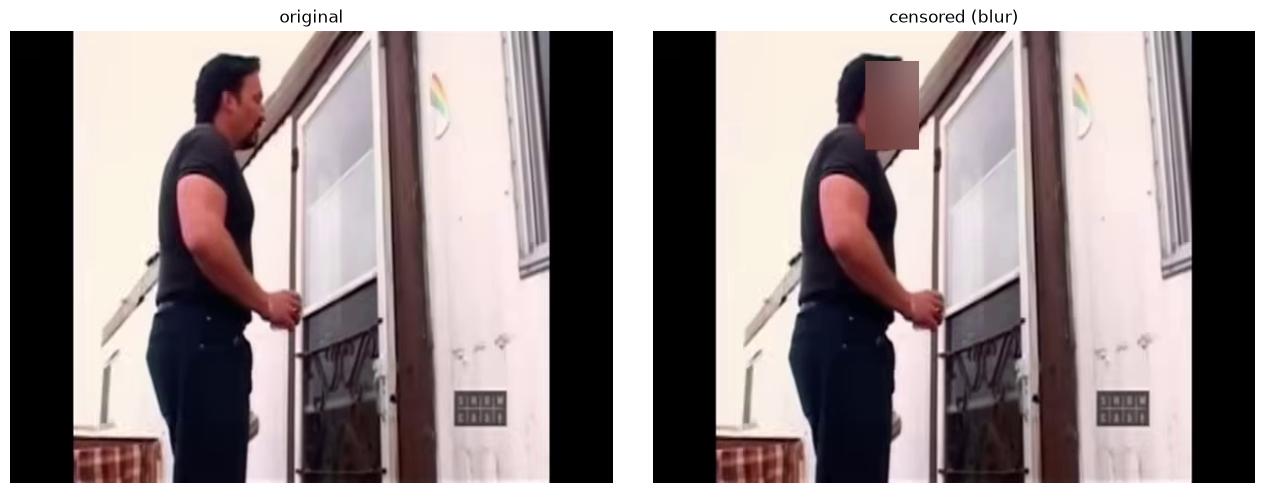

In [31]:
# ---- verbatim from blurfaces.py ----
def apply_censor(frame, bbox, method):
    x1, y1, x2, y2 = (max(0, int(v)) for v in bbox)
    fh, fw = frame.shape[:2]
    x2, y2 = min(fw, x2), min(fh, y2)
    if x2 <= x1 or y2 <= y1:
        return
    roi = frame[y1:y2, x1:x2]
    if method == "blackout":
        frame[y1:y2, x1:x2] = 0
    elif method == "pixel":
        rh, rw = roi.shape[:2]
        small = cv2.resize(roi, (8, 8), interpolation=cv2.INTER_AREA)
        frame[y1:y2, x1:x2] = cv2.resize(small, (rw, rh), interpolation=cv2.INTER_AREA)
    elif method == "bar":
        rh = y2 - y1
        bar_top = y1 + int(rh * 0.3)
        bar_bot = y1 + int(rh * 0.55)
        frame[bar_top:bar_bot, x1:x2] = 0
    else:
        frame[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (0, 0), 30)


def pad_box(box, pad, w, h):
    x1, y1, x2, y2 = box
    dx, dy = (x2 - x1) * pad, (y2 - y1) * pad
    return [max(0, x1 - dx), max(0, y1 - dy), min(w, x2 + dx), min(h, y2 + dy)]


# ---- face detection backends ----
_ins_app = None

def detect_insightface(frame):
    """Returns [(bbox, embedding_or_None)]."""
    global _ins_app
    if _ins_app is None:
        import insightface
        _ins_app = insightface.app.FaceAnalysis(name=CFG.model_pack)
        _ins_app.prepare(ctx_id=0, det_size=(CFG.det_size, CFG.det_size))
    return [(f.bbox, f.normed_embedding) for f in _ins_app.get(frame)]


_yunet = None

def detect_yunet(frame):
    """OpenCV YuNet — no compiler needed, but no embeddings (mode='all' only)."""
    global _yunet
    h, w = frame.shape[:2]
    if _yunet is None:
        mp = WORK_DIR / "face_detection_yunet_2023mar.onnx"
        if not mp.exists():
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/opencv/opencv_zoo/raw/main/models/"
                "face_detection_yunet/face_detection_yunet_2023mar.onnx", mp)
        _yunet = cv2.FaceDetectorYN.create(str(mp), "", (w, h), 0.6, 0.3, 5000)
    _yunet.setInputSize((w, h))
    _, faces = _yunet.detect(frame)
    if faces is None:
        return []
    return [(np.array([x, y, x + fw, y + fh], np.float32), None)
            for x, y, fw, fh, *_ in faces]


FACE_BACKENDS = {"insightface": detect_insightface, "yunet": detect_yunet}


def load_reference():
    if CFG.mode == "all":
        return None
    if CFG.face_backend != "insightface":
        raise ValueError("target/exclude modes need face_backend='insightface'")
    img = cv2.imread(CFG.face_file)
    if img is None:
        raise IOError(f"cannot read {CFG.face_file}")
    faces = detect_insightface(img)
    if not faces:
        raise ValueError(f"no face found in {CFG.face_file}")
    return faces[0][1]


def censor_video(src, dst):
    ref = load_reference()
    detect = FACE_BACKENDS[CFG.face_backend]

    def should_censor(emb):
        if CFG.mode == "all":
            return True
        m = float(np.dot(emb, ref)) >= CFG.threshold
        return m if CFG.mode == "target" else not m

    writer = frame_writer(dst, VW, VH, VFPS)
    held, n_hits, n_held = [], 0, 0          # [[box, frames_left], ...]
    try:
        for frame in tqdm(frame_reader(src, N_FRAMES), total=N_FRAMES, desc="censoring"):
            boxes = [pad_box(b, CFG.box_pad, VW, VH)
                     for b, emb in detect(frame) if should_censor(emb)]
            if boxes:
                held = [[b, CFG.miss_hold] for b in boxes]
                n_hits += len(boxes)
            else:
                # Action footage: motion blur / profile views drop detections for
                # a frame or two. Reuse the last box rather than exposing the face.
                held = [[b, t - 1] for b, t in held if t > 1]
                boxes = [b for b, _ in held]
                n_held += len(boxes)
            for b in boxes:
                apply_censor(frame, b, CFG.blur_method)
            writer.write(frame)
    finally:
        writer.release()
    print(f"detections={n_hits}  carried-over boxes={n_held}  ->  {dst.name}")


BLURRED = OUTPUT_DIR / f"{STEM}_1_blur_raw_{CFG.blur_method}.mp4"
censor_video(VIDEO, BLURRED)

# side-by-side sanity check on one frame
_o = next(frame_reader(VIDEO)); _b = next(frame_reader(BLURRED))
fig, ax = plt.subplots(1, 2, figsize=(13, 13 * VH / VW / 2))
for a, im, t in zip(ax, (_o, _b), ("original", f"censored ({CFG.blur_method})")):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Pose Estimation after Blur

Same backend, same settings, censored video.

In [32]:
POSE_AFTER = estimate_pose(BLURRED, f"{STEM}_after_{CFG.blur_method}")
print(f"people detected: before={sum(len(f) for f in POSE_BEFORE)}  "
      f"after={sum(len(f) for f in POSE_AFTER)}")

cached -> pose_Jim Lahey Falls Down - JackKehoe (480p)_after_blur_torchvision.npy
people detected: before=276  after=298


## 5. Comparison between before and after blur

People are matched frame-by-frame between the two runs by bounding-box IoU (greedy, highest IoU first), so a person who moves across the frame still lines up. Unmatched people on the "before" side are **lost detections** — the most severe failure mode, and the one to watch for in action footage.

Metrics, per matched pair:
- **displacement** — pixel distance per keypoint, normalised by the person's bbox diagonal
- **PCK@t** — fraction of keypoints landing within `t x diagonal` of ground truth
- **OKS** — the COCO similarity used by keypoint mAP
- **confidence delta** — how much the estimator's own certainty drops

Everything is split **face keypoints (nose/eyes/ears) vs body keypoints**, since only the face is touched: a large body-keypoint error means the blur disturbed the estimator globally, not just locally.

Only keypoints the *before* run was confident about (`CFG.kpt_vis_thr`) are scored. Joints it never saw — occluded limbs, legs cropped out of frame — have no meaningful position, and including them buries the real effect under noise. In action footage that is a lot of joints, so this threshold matters more here than it would on standing subjects.

In [33]:
def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter <= 0:
        return 0.0
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0


def match_frame(before, after, min_iou=0.3):
    """Greedy IoU matching. -> (pairs, n_lost, n_spurious)."""
    pairs, used, taken_b = [], set(), set()
    cand = sorted(((iou(b["box"], a["box"]), i, j)
                   for i, b in enumerate(before) for j, a in enumerate(after)),
                  key=lambda z: -z[0])
    for v, i, j in cand:
        if v < min_iou or i in taken_b or j in used:
            continue
        taken_b.add(i); used.add(j)
        pairs.append((before[i], after[j]))
    return pairs, len(before) - len(taken_b), len(after) - len(used)


def oks(kb, ka, box):
    area = max(1.0, (box[2]-box[0]) * (box[3]-box[1]))
    d2 = (kb[:, 0]-ka[:, 0])**2 + (kb[:, 1]-ka[:, 1])**2
    e = d2 / (2 * (OKS_SIGMAS**2) * area)
    vis = kb[:, 2] > CFG.kpt_vis_thr
    return float(np.exp(-e[vis]).mean()) if vis.any() else np.nan


# ---- sweep the video ----
K = len(COCO_KPTS)
disp_n = [[] for _ in range(K)]      # normalised displacement per keypoint
conf_b = [[] for _ in range(K)]
conf_a = [[] for _ in range(K)]
per_frame = []                       # (frame_idx, mean_norm_disp, oks, n_lost)
lost = spurious = matched = 0

for t, (fb, fa) in enumerate(zip(POSE_BEFORE, POSE_AFTER)):
    pairs, nl, ns = match_frame(fb, fa)
    lost += nl; spurious += ns; matched += len(pairs)
    fd, fo = [], []
    for pb, pa in pairs:
        kb, ka, box = pb["kpts"], pa["kpts"], pb["box"]
        diag = np.hypot(box[2]-box[0], box[3]-box[1]) or 1.0
        d = np.hypot(kb[:, 0]-ka[:, 0], kb[:, 1]-ka[:, 1]) / diag
        # A joint the estimator never saw in the first place (occluded, out of
        # frame) has a meaningless "position", and scoring it would drown the
        # real signal in noise. Only keypoints the BEFORE run was confident
        # about form the ground truth.
        vis = kb[:, 2] > CFG.kpt_vis_thr
        for k in np.where(vis)[0]:
            disp_n[k].append(d[k]); conf_b[k].append(kb[k, 2]); conf_a[k].append(ka[k, 2])
        if vis.any():
            fd.append(float(d[vis].mean())); fo.append(oks(kb, ka, box))
    per_frame.append((t, np.nanmean(fd) if fd else np.nan,
                      np.nanmean(fo) if fo else np.nan, nl))

disp_n = [np.array(x, np.float32) for x in disp_n]
ALL_D = np.concatenate([d for d in disp_n if len(d)]) if matched else np.array([])

print(f"matched people : {matched}")
print(f"LOST (blur made the person undetectable) : {lost}"
      f"   ({lost / max(1, matched + lost):.1%} of before-detections)")
print(f"spurious new detections after blur       : {spurious}\n")
for thr in CFG.pck_thresholds:
    print(f"  PCK@{thr:.2f} = {(ALL_D <= thr).mean():.3f}" if ALL_D.size else "  no data")
print(f"\n  mean OKS = {np.nanmean([o for _, _, o, _ in per_frame]):.4f}")

matched people : 258
LOST (blur made the person undetectable) : 18   (6.5% of before-detections)
spurious new detections after blur       : 40

  PCK@0.05 = 0.748
  PCK@0.10 = 0.840
  PCK@0.20 = 0.919

  mean OKS = 0.6586


In [34]:
# ---- per-keypoint table ----
rows = []
for k, name in enumerate(COCO_KPTS):
    d = disp_n[k]
    if not len(d):
        continue
    rows.append((name, GROUP_OF[k],
                 float(d.mean()), float(np.median(d)), float((d <= 0.05).mean()),
                 float(np.mean(conf_b[k])), float(np.mean(conf_a[k]))))

hdr = ("keypoint".ljust(16) + "group".ljust(7) + "mean disp".rjust(10)
       + "median".rjust(9) + "PCK@.05".rjust(9) + "conf b".rjust(8)
       + "conf a".rjust(8) + "d conf".rjust(8))
print(hdr); print("-" * len(hdr))
for n, g, m, md, p, cb, ca in rows:
    print(f"{n:<16}{g:<7}{m:>10.4f}{md:>9.4f}{p:>9.3f}{cb:>8.3f}{ca:>8.3f}{ca-cb:>+8.3f}")

# ---- per-group roll-up ----
group_d = {g: np.concatenate([disp_n[k] for k in ks if len(disp_n[k])])
           for g, ks in KPT_GROUPS.items()
           if any(len(disp_n[k]) for k in ks)}
face_d = np.concatenate([disp_n[k] for k in FACE_KPTS if len(disp_n[k])])
body_d = np.concatenate([disp_n[k] for k in BODY_KPTS if len(disp_n[k])])

print("-" * len(hdr))
print(f"{'GROUP':<16}{'n':>7}{'mean disp':>10}{'median':>9}{'PCK@.05':>9}"
      f"{'':>16}{'d conf':>8}")
for g in GROUP_ORDER:
    if g not in group_d:
        continue
    d = group_d[g]
    dc = np.mean([r[6] - r[5] for r in rows if r[1] == g])
    print(f"{g.upper():<16}{len(d):>7}{d.mean():>10.4f}{np.median(d):>9.4f}"
          f"{(d <= 0.05).mean():>9.3f}{'':>16}{dc:>+8.3f}")
print("n = scored keypoint samples across all frames, not distinct joints.")

print(f"\nface vs rest-of-body error ratio: "
      f"{face_d.mean() / max(1e-9, body_d.mean()):.2f}x")
_far = max(group_d, key=lambda g: group_d[g].mean())
print(f"worst-hit group: {_far} ({group_d[_far].mean():.4f} mean displacement)")

keypoint        group   mean disp   median  PCK@.05  conf b  conf a  d conf
---------------------------------------------------------------------------
nose            face       0.1110   0.0605    0.458   0.984   0.810  -0.173
left_eye        face       0.1113   0.0482    0.508   0.965   0.767  -0.197
right_eye       face       0.1035   0.0531    0.498   0.971   0.873  -0.098
left_ear        face       0.0619   0.0329    0.679   0.991   0.898  -0.093
right_ear       face       0.0641   0.0380    0.567   0.976   0.920  -0.056
left_shoulder   torso      0.0283   0.0112    0.831   0.963   0.897  -0.065
right_shoulder  torso      0.0292   0.0107    0.825   0.946   0.878  -0.068
left_elbow      arms       0.0534   0.0126    0.748   0.925   0.851  -0.074
right_elbow     arms       0.0235   0.0064    0.900   0.963   0.943  -0.020
left_wrist      arms       0.0690   0.0060    0.764   0.906   0.885  -0.021
right_wrist     arms       0.0144   0.0038    0.952   0.972   0.964  -0.007
left_hip    

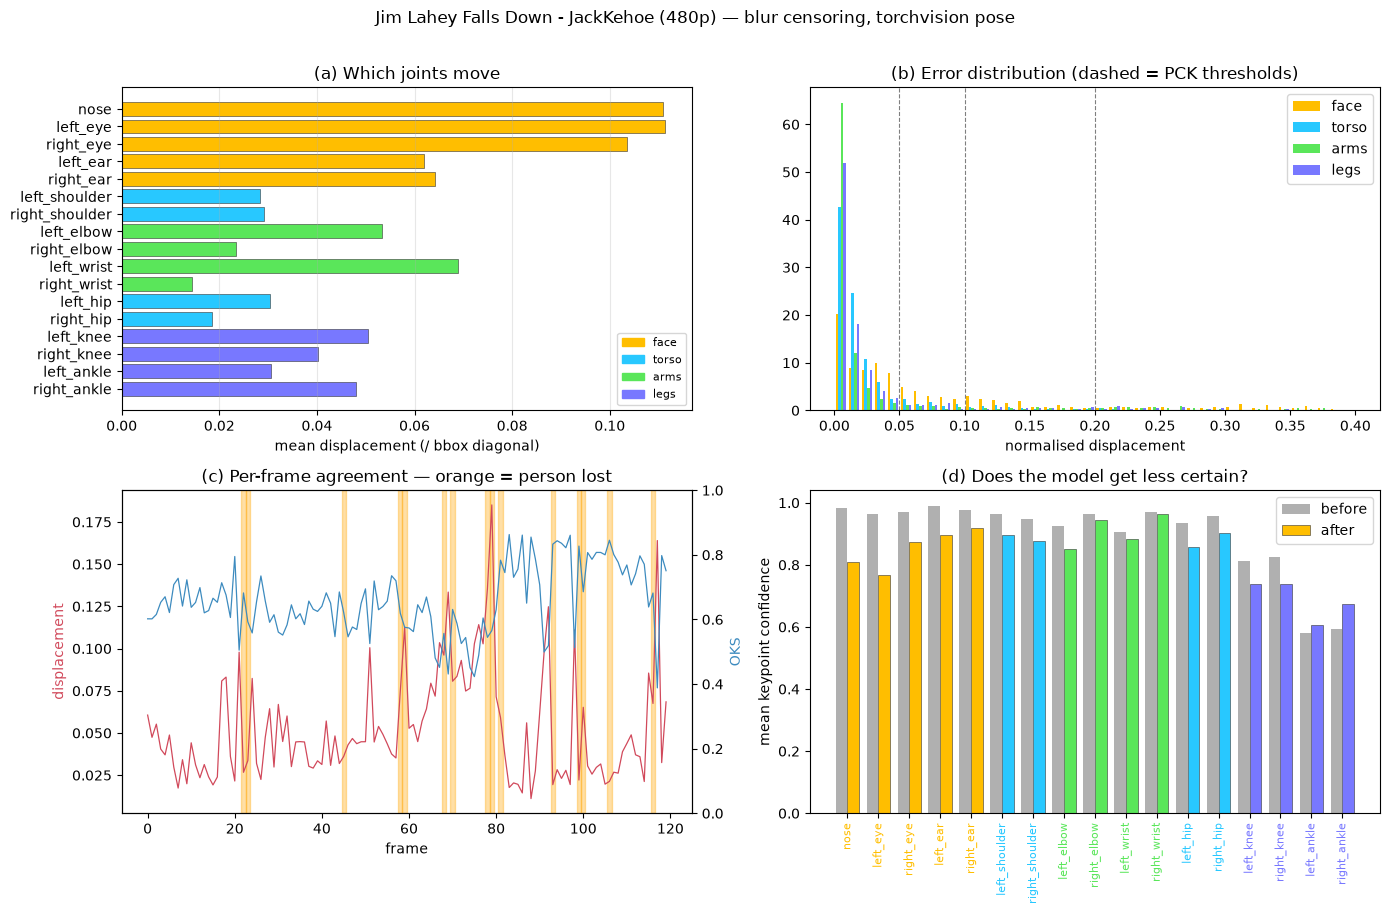

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# (a) per-keypoint displacement, coloured by group like the video overlay
names = [r[0] for r in rows]; means = [r[2] for r in rows]
cols = [GROUP_HEX[r[1]] for r in rows]
ax[0,0].barh(names, means, color=cols, edgecolor="#333", linewidth=.4)
ax[0,0].invert_yaxis(); ax[0,0].set_xlabel("mean displacement (/ bbox diagonal)")
ax[0,0].set_title("(a) Which joints move"); ax[0,0].grid(axis="x", alpha=.3)
ax[0,0].legend(handles=[plt.Rectangle((0,0),1,1, color=GROUP_HEX[g], label=g)
                        for g in GROUP_ORDER], fontsize=8, loc="lower right")

# (b) error distribution per group
_gk = [g for g in GROUP_ORDER if g in group_d]
ax[0,1].hist([group_d[g] for g in _gk], bins=40, range=(0, 0.4), label=_gk,
             color=[GROUP_HEX[g] for g in _gk], density=True)
for thr in CFG.pck_thresholds:
    ax[0,1].axvline(thr, ls="--", c="k", lw=.8, alpha=.5)
ax[0,1].set_xlabel("normalised displacement"); ax[0,1].legend()
ax[0,1].set_title("(b) Error distribution (dashed = PCK thresholds)")

# (c) stability over time
t = [p[0] for p in per_frame]
ax[1,0].plot(t, [p[1] for p in per_frame], lw=.9, c="#d1495b")
ax[1,0].set_xlabel("frame"); ax[1,0].set_ylabel("displacement", color="#d1495b")
a2 = ax[1,0].twinx(); a2.plot(t, [p[2] for p in per_frame], lw=.9, c="#3d8bbf")
a2.set_ylabel("OKS", color="#3d8bbf"); a2.set_ylim(0, 1)
for ti, _, _, nl in per_frame:
    if nl:
        ax[1,0].axvspan(ti - .5, ti + .5, color="orange", alpha=.35)
ax[1,0].set_title("(c) Per-frame agreement — orange = person lost")

# (d) confidence shift — grey is before, group colour is after
x = np.arange(len(rows)); wdt = .38
ax[1,1].bar(x - wdt/2, [r[5] for r in rows], wdt, label="before", color="#b0b0b0")
ax[1,1].bar(x + wdt/2, [r[6] for r in rows], wdt, label="after",
            color=cols, edgecolor="#333", linewidth=.4)
ax[1,1].set_xticks(x); ax[1,1].set_xticklabels(names, rotation=90, fontsize=8)
for tick, r in zip(ax[1,1].get_xticklabels(), rows):
    tick.set_color(GROUP_HEX[r[1]])
ax[1,1].set_ylabel("mean keypoint confidence"); ax[1,1].legend()
ax[1,1].set_title("(d) Does the model get less certain?")

plt.suptitle(f"{STEM} — {CFG.blur_method} censoring, {CFG.pose_backend} pose", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{STEM}_{CFG.blur_method}_metrics.png", dpi=140, bbox_inches="tight")
plt.show()

### Visual preview — the three renders

One pass over both videos produces four files:

| file | what it is |
| --- | --- |
| `1_blur_raw.mp4` | the censored video, no overlay — the deliverable a privacy pipeline would ship |
| `2_pose_before.mp4` | original + skeleton — the ground truth |
| `3_pose_after.mp4` | censored + skeleton — what the estimator makes of the blurred face |
| `4_compare.mp4` | before and after side by side |

`1_blur_raw.mp4` is already written by section 3, so this cell renders the other three and samples the comparison into an animated GIF for inline display. The GIF is the reliable preview: it renders in any notebook regardless of which codecs OpenCV found.

**Reading the overlay.** The skeleton is coloured by anatomical group, with a key burned into each frame:

| colour | group | joints |
| --- | --- | --- |
| amber | **face** | nose, eyes, ears |
| cyan | **torso** | shoulders, hips |
| green | **arms** | elbows, wrists |
| periwinkle | **legs** | knees, ankles |

Only the face is censored, so the colours make the central question visible directly: if the damage is confined to amber, blurring is safe for body pose; if cyan, green or periwinkle also drift, the blur is disturbing the estimator globally.

Joints that moved more than `PCK@0.1` between the two runs are ringed in **red** on the *after* panel — deliberately a colour no group uses.

In [36]:
def draw_pose(img, people, ref=None, mark_thr=0.10, kpt_thr=None):
    """Skeleton coloured by anatomical group (see GROUP_BGR).

    Bones are drawn before joints so the dots sit on top, and each joint takes
    its own group's colour rather than the colour of whatever bone drew last.
    """
    kpt_thr = CFG.draw_kpt_thr if kpt_thr is None else kpt_thr
    img = img.copy()
    for p in people:
        k = p["kpts"]
        for (i, j), grp in SKELETON_GROUPED:
            if k[i, 2] > kpt_thr and k[j, 2] > kpt_thr:
                cv2.line(img, tuple(k[i, :2].astype(int)), tuple(k[j, :2].astype(int)),
                         GROUP_BGR[grp], 2, cv2.LINE_AA)
        for n in range(len(k)):
            if k[n, 2] > kpt_thr:
                c = tuple(k[n, :2].astype(int))
                cv2.circle(img, c, 4, (30, 30, 30), -1, cv2.LINE_AA)      # outline
                cv2.circle(img, c, 3, GROUP_BGR[GROUP_OF[n]], -1, cv2.LINE_AA)
    if ref is not None:
        for pb, pa in ref:
            diag = np.hypot(pb["box"][2]-pb["box"][0], pb["box"][3]-pb["box"][1]) or 1.0
            d = np.hypot(pb["kpts"][:,0]-pa["kpts"][:,0], pb["kpts"][:,1]-pa["kpts"][:,1]) / diag
            for n in np.where((d > mark_thr) & (pb["kpts"][:, 2] > kpt_thr))[0]:
                cv2.circle(img, tuple(pa["kpts"][n, :2].astype(int)), 11, MOVED_BGR, 2, cv2.LINE_AA)
    return img


def label(img, text):
    cv2.putText(img, text, (12, 34), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 4, cv2.LINE_AA)
    cv2.putText(img, text, (12, 34), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
    return img


def draw_legend(img, show_moved=False):
    """Colour key along the bottom-left, so the video explains itself.

    Sizes scale with frame width: the GIF is drawn on an already-downscaled
    frame, and a legend sized for 1280px would be unreadable there.
    """
    entries = [(g, GROUP_BGR[g]) for g in GROUP_ORDER]
    if show_moved:
        entries.append(("moved", MOVED_BGR))
    w = img.shape[1]
    fs = max(0.42, min(1.0, w / 1400))
    th = 1 if w < 1200 else 2
    sw = max(12, int(w / 55))
    bh = int(22 * fs / 0.5)                       # legend band height
    x, y = int(w / 90) + 6, img.shape[0] - int(bh * 0.5)
    gap = int(sw * 0.7)

    def tw(s):
        return cv2.getTextSize(s, cv2.FONT_HERSHEY_SIMPLEX, fs, th)[0][0]

    width = sum(sw + 6 + tw(n) + gap for n, _ in entries)
    cv2.rectangle(img, (x - 6, y - bh), (x + width, y + int(bh * 0.35)), (0, 0, 0), -1)
    cx = x
    for name, bgr in entries:
        cv2.rectangle(img, (cx, y - int(bh * 0.72)), (cx + sw, y - int(bh * 0.18)), bgr, -1)
        cx += sw + 6
        cv2.putText(img, name, (cx, y - int(bh * 0.2)), cv2.FONT_HERSHEY_SIMPLEX, fs,
                    (255, 255, 255), th, cv2.LINE_AA)
        cx += tw(name) + gap
    return img


POSE_BEFORE_MP4 = OUTPUT_DIR / f"{STEM}_2_pose_before.mp4"
POSE_AFTER_MP4  = OUTPUT_DIR / f"{STEM}_3_pose_after_{CFG.blur_method}.mp4"
COMPARE_MP4     = OUTPUT_DIR / f"{STEM}_4_compare_{CFG.blur_method}.mp4"


def render_all(grid_n=6):
    """Single pass over both videos -> three mp4s + GIF frames + sample stills."""
    w_before = frame_writer(POSE_BEFORE_MP4, VW, VH, VFPS)
    w_after  = frame_writer(POSE_AFTER_MP4,  VW, VH, VFPS)
    w_cmp    = frame_writer(COMPARE_MP4, VW * 2, VH, VFPS)

    stills = set(np.linspace(0, N_FRAMES - 1, grid_n).astype(int).tolist())
    gif_at = set(np.linspace(0, N_FRAMES - 1,
                             min(CFG.gif_max_frames, N_FRAMES)).astype(int).tolist()) \
             if CFG.gif_width else set()
    samples, gif_frames = [], []

    ro, rb = frame_reader(VIDEO, N_FRAMES), frame_reader(BLURRED, N_FRAMES)
    try:
        for t, (fo, fb) in enumerate(tqdm(zip(ro, rb), total=N_FRAMES, desc="rendering")):
            pb, pa = POSE_BEFORE[t], POSE_AFTER[t]
            pairs, _, _ = match_frame(pb, pa)

            # Legend-free panels first: the GIF gets its own legend after
            # downscaling, so it stays readable at GIF size.
            bare_l = label(draw_pose(fo, pb), "BEFORE — original")
            bare_r = label(draw_pose(fb, pa, ref=pairs), f"AFTER — {CFG.blur_method}")
            left  = draw_legend(bare_l.copy())
            right = draw_legend(bare_r.copy(), show_moved=True)
            combo = np.hstack([left, right])

            w_before.write(left); w_after.write(right); w_cmp.write(combo)
            if t in stills:
                samples.append((t, combo))
            if t in gif_at:
                gw = CFG.gif_width
                bare = np.hstack([bare_l, bare_r])
                small = cv2.resize(bare, (gw, int(gw * bare.shape[0] / bare.shape[1])),
                                   interpolation=cv2.INTER_AREA)
                draw_legend(small, show_moved=True)
                gif_frames.append(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
    finally:
        for w in (w_before, w_after, w_cmp):
            w.release()
    return samples, gif_frames


samples, gif_frames = render_all()
for f in (BLURRED, POSE_BEFORE_MP4, POSE_AFTER_MP4, COMPARE_MP4):
    print(f"  {f.name:<46}{f.stat().st_size/1e6:7.2f} MB")

rendering: 100%|██████████| 120/120 [00:02<00:00, 55.95it/s]


  Jim Lahey Falls Down - JackKehoe (480p)_1_blur_raw_blur.mp4   4.50 MB
  Jim Lahey Falls Down - JackKehoe (480p)_2_pose_before.mp4   4.61 MB
  Jim Lahey Falls Down - JackKehoe (480p)_3_pose_after_blur.mp4   4.61 MB
  Jim Lahey Falls Down - JackKehoe (480p)_4_compare_blur.mp4   9.22 MB


Jim Lahey Falls Down - JackKehoe (480p)_compare_blur.gif  —  40 frames, 3.04 MB


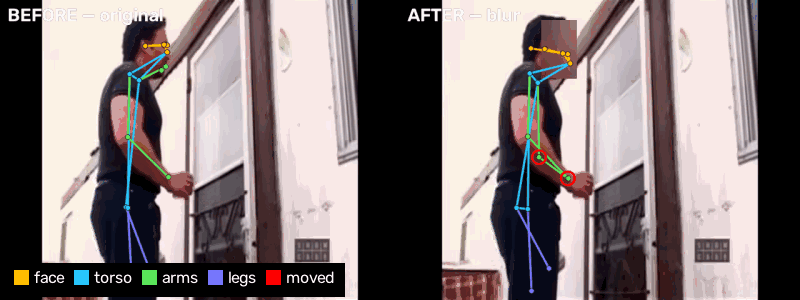

In [37]:
# ---- animated GIF, shown inline ----
from IPython.display import Image, display

GIF = OUTPUT_DIR / f"{STEM}_compare_{CFG.blur_method}.gif"
if gif_frames:
    from PIL import Image as PILImage
    pil = [PILImage.fromarray(f).quantize(colors=CFG.gif_colors,
                                          method=PILImage.Quantize.FASTOCTREE)
           for f in gif_frames]
    pil[0].save(GIF, save_all=True, append_images=pil[1:],
                duration=int(1000 / CFG.gif_fps), loop=0, optimize=True)
    print(f"{GIF.name}  —  {len(pil)} frames, {GIF.stat().st_size/1e6:.2f} MB")
    display(Image(filename=str(GIF)))
else:
    print("GIF disabled (CFG.gif_width = 0)")

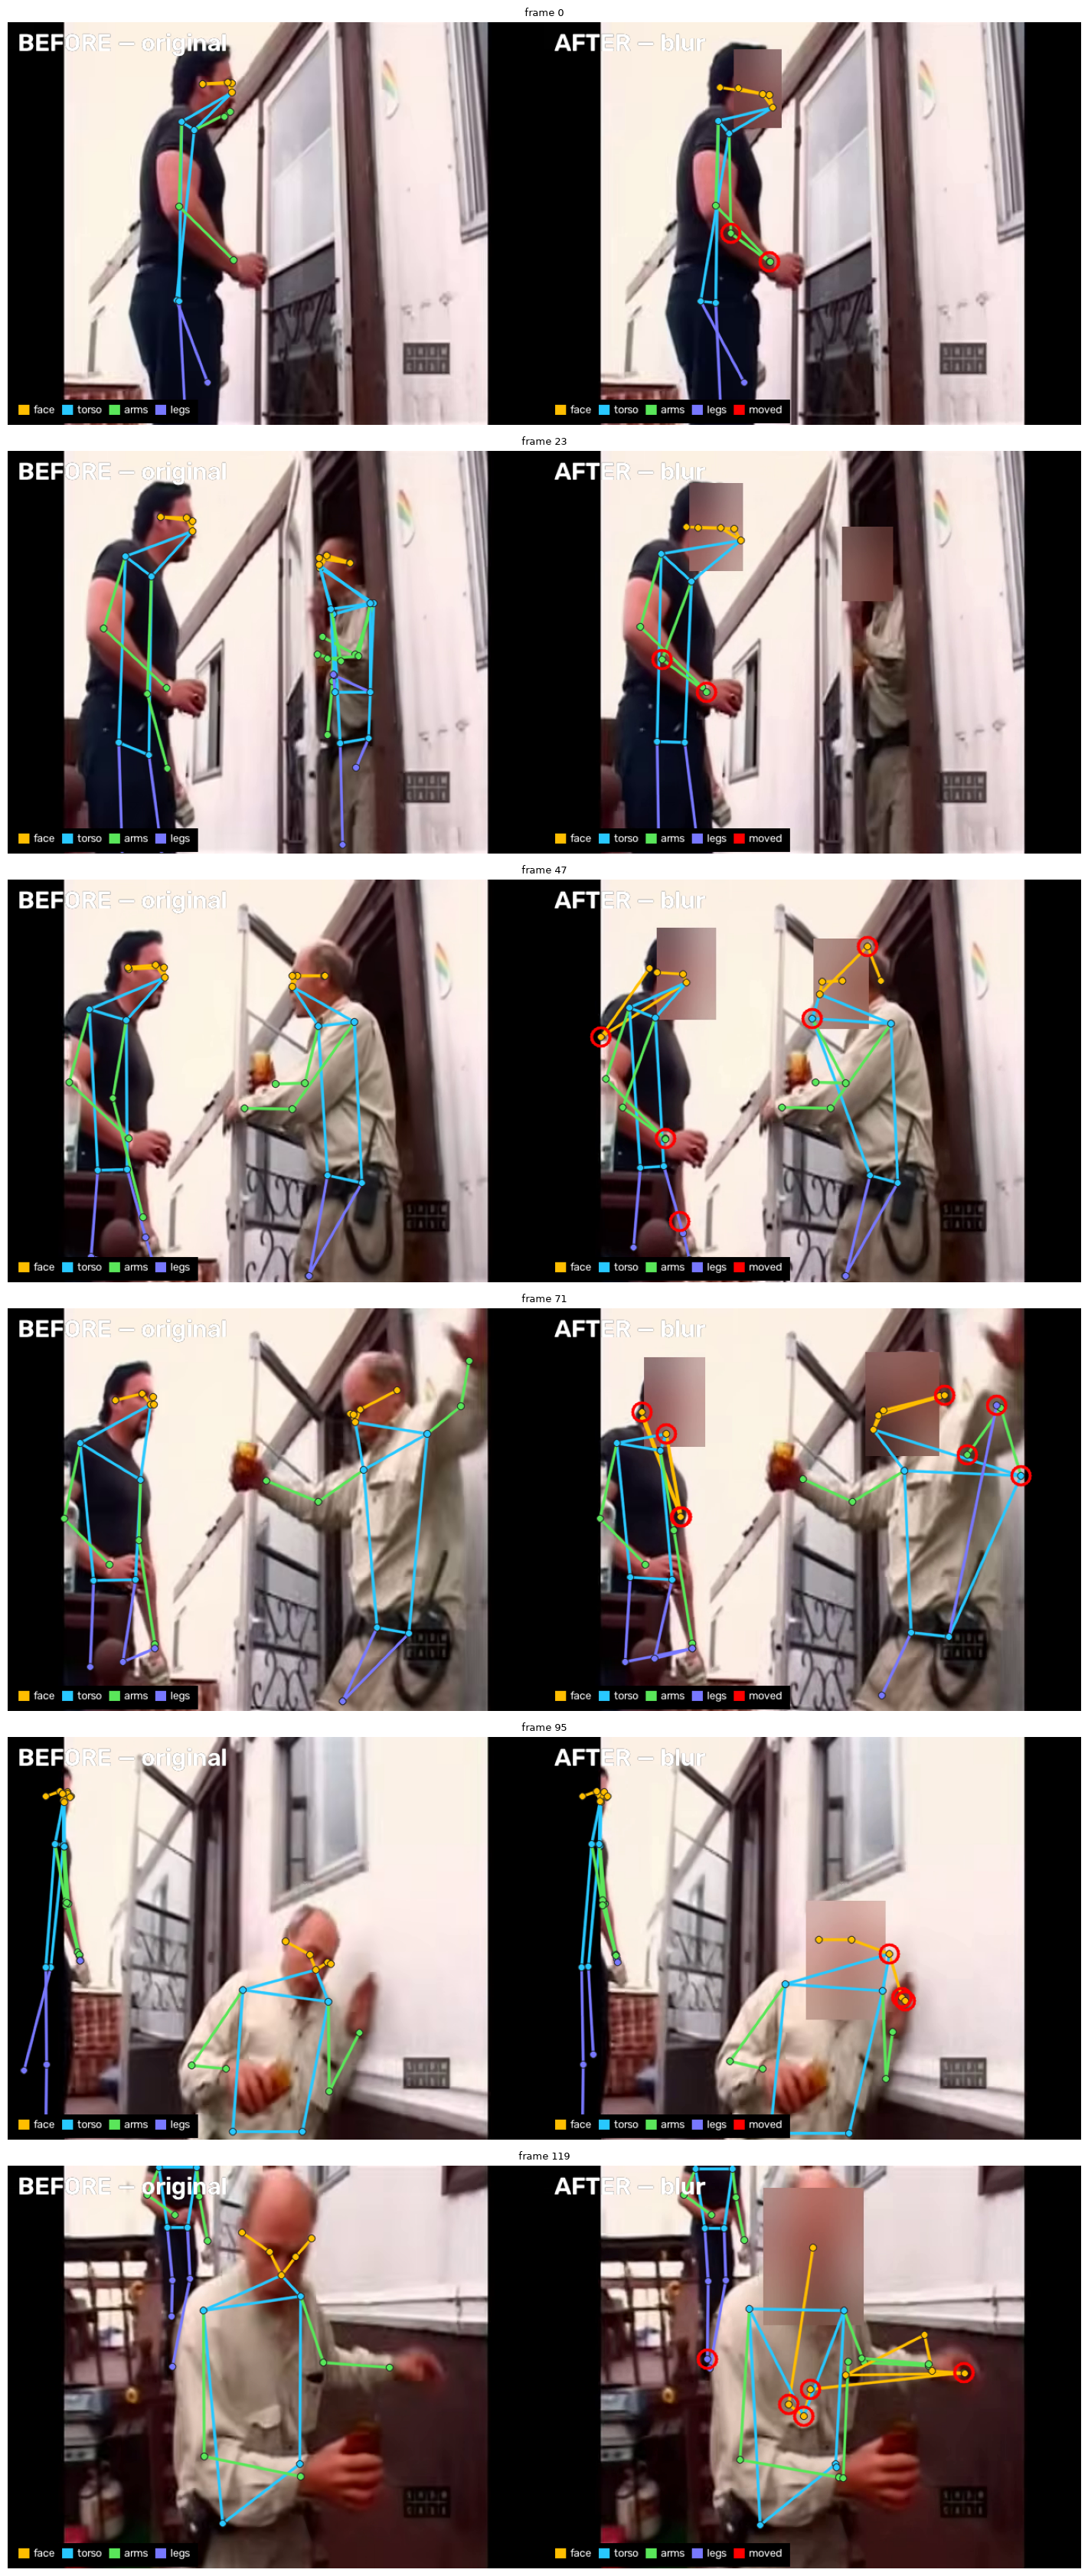

In [38]:
# ---- still frames, easier to read than the GIF for close inspection ----
fig, axes = plt.subplots(len(samples), 1,
                         figsize=(15, 15 * VH / (VW * 2) * len(samples)))
for a, (t, im) in zip(np.atleast_1d(axes), samples):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.axis("off")
    a.set_title(f"frame {t}", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{STEM}_{CFG.blur_method}_stills.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Export Result to Folder

Collects all four videos, the GIF, both figures, raw keypoints for each run, and a JSON summary into one folder per (video, censor method, pose backend), so separate runs can be compared against each other.

In [39]:
RUN_DIR = OUTPUT_DIR / f"{STEM}__{CFG.blur_method}__{CFG.pose_backend}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

summary = {
    "video": VIDEO.name, "frames": N_FRAMES, "resolution": [VW, VH], "fps": VFPS,
    "config": {k: (str(v) if isinstance(v, Path) else v) for k, v in CFG.__dict__.items()},
    "detections": {"matched": matched, "lost": lost, "spurious": spurious,
                   "lost_rate": lost / max(1, matched + lost)},
    "pck": {f"@{t:.2f}": float((ALL_D <= t).mean()) for t in CFG.pck_thresholds},
    "mean_oks": float(np.nanmean([o for _, _, o, _ in per_frame])),
    "mean_norm_displacement": {"all": float(ALL_D.mean()),
                               "face": float(face_d.mean()), "body": float(body_d.mean())},
    "per_group": {g: {"n_samples": int(d.size),
                      "mean_disp": float(d.mean()),
                      "median_disp": float(np.median(d)),
                      "pck_005": float((d <= 0.05).mean()),
                      "mean_conf_delta": float(np.mean([r[6] - r[5] for r in rows
                                                        if r[1] == g]))}
                  for g, d in group_d.items()},
    "per_keypoint": {r[0]: {"group": r[1], "mean_disp": r[2], "median_disp": r[3],
                            "pck_005": r[4], "conf_before": r[5], "conf_after": r[6]}
                     for r in rows},
}
(RUN_DIR / "summary.json").write_text(json.dumps(summary, indent=2))
np.save(RUN_DIR / "keypoints_before.npy", np.array(POSE_BEFORE, dtype=object), allow_pickle=True)
np.save(RUN_DIR / "keypoints_after.npy", np.array(POSE_AFTER, dtype=object), allow_pickle=True)

artifacts = [BLURRED, POSE_BEFORE_MP4, POSE_AFTER_MP4, COMPARE_MP4, GIF,
             OUTPUT_DIR / f"{STEM}_{CFG.blur_method}_metrics.png",
             OUTPUT_DIR / f"{STEM}_{CFG.blur_method}_stills.png"]
for f in artifacts:
    if f.exists() and f.parent != RUN_DIR:
        shutil.move(str(f), RUN_DIR / f.name)

print(f"exported -> {RUN_DIR}")
for f in sorted(RUN_DIR.iterdir()):
    print(f"   {f.name:<44}{f.stat().st_size/1e6:7.2f} MB")

exported -> c:\.FILES\..MY STUFF\..KARIN\.UI\.SEM 6\skripsi\..RA-Pak-Edy\output\Jim Lahey Falls Down - JackKehoe (480p)__blur__torchvision
   Jim Lahey Falls Down - JackKehoe (480p)_1_blur_raw_blur.mp4   4.50 MB
   Jim Lahey Falls Down - JackKehoe (480p)_2_pose_before.mp4   4.61 MB
   Jim Lahey Falls Down - JackKehoe (480p)_3_pose_after_blur.mp4   4.61 MB
   Jim Lahey Falls Down - JackKehoe (480p)_4_compare_blur.mp4   9.22 MB
   Jim Lahey Falls Down - JackKehoe (480p)_blur_metrics.png   0.24 MB
   Jim Lahey Falls Down - JackKehoe (480p)_blur_stills.png   4.04 MB
   Jim Lahey Falls Down - JackKehoe (480p)_compare_blur.gif   3.04 MB
   keypoints_after.npy                            0.09 MB
   keypoints_before.npy                           0.08 MB
   summary.json                                   0.01 MB


### Running the sweep

To answer *which* censoring method is safest for pose, re-run sections 3-6 once per `blur_method` and compare the `summary.json` files:

```python
for m in ("bar", "blur", "pixel", "blackout"):
    CFG.blur_method = m
    # then re-run cells 3 -> 6
```

Then collect them:

```python
import pandas as pd
recs = []
for p in sorted(OUTPUT_DIR.glob(f"{STEM}__*")):
    s = json.loads((p / "summary.json").read_text())
    recs.append({"method": s["config"]["blur_method"], **s["pck"],
                 "oks": s["mean_oks"], "lost_rate": s["detections"]["lost_rate"],
                 "face_err": s["mean_norm_displacement"]["face"],
                 "body_err": s["mean_norm_displacement"]["body"]})
pd.DataFrame(recs)
```